<a href="https://colab.research.google.com/github/anuragpatil811/Machine-Learning/blob/main/Student_Admission_LogReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('/content/student1.csv')
df.head(3)

,name,gmat,gpa,exp,admitted,country
0,samir,780,4.0,3,1,Ind
1,kaushal,750,3.9,4,1,Ind
2,nandan,690,3.3,3,0,Ind


In [3]:
df.drop(columns=['name', 'country'], inplace=True)

In [4]:
df.isnull().sum()

,0
gmat,0
gpa,0
exp,0
admitted,0


In [5]:
df.duplicated().sum()

np.int64(4)

In [6]:
df.drop_duplicates(inplace=True)

<Axes: ylabel='gmat'>

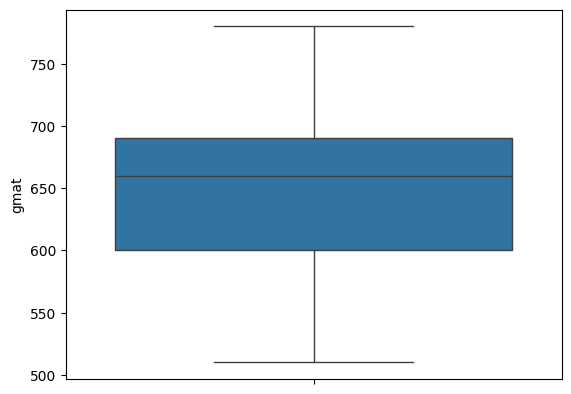

In [16]:
import seaborn as sns
sns.boxplot(data=df, y="gmat")

In [10]:
df["exp"].describe()

,exp
count,38.000000
mean,3.894737
std,3.754561
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,24.000000


In [11]:
q1 = 2.0
q3 = 5.0
IQR = q3 - q1

In [12]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [13]:
df = df[(df["exp"]>lb)&(df["exp"]<ub)]

<Axes: ylabel='exp'>

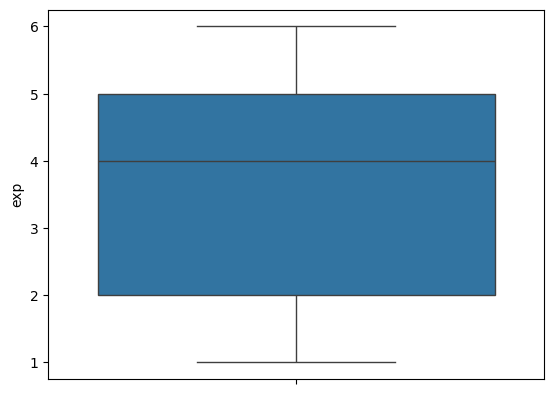

In [14]:
sns.boxplot(data=df, y="exp")

In [18]:
x = df.drop("admitted", axis=1)
y = df["admitted"]

In [20]:
from numpy.random import random_sample
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [23]:
model.fit(X_train, y_train)

LogisticRegression()

In [24]:
y_predict = model.predict(X_test)

In [25]:
#Training Score
model.score(X_train, y_train)

0.9310344827586207

In [26]:
#Testing Score
model.score(X_test, y_test)

0.75

In [27]:
y_predict

array([1, 1, 1, 0, 0, 1, 0, 0])

In [28]:
#Create Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_predict)
print(cm)

[[4 2]
 [0 2]]


In [29]:
#Classification Report
cr = classification_report(y_test, y_predict)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.50      1.00      0.67         2

    accuracy                           0.75         8
   macro avg       0.75      0.83      0.73         8
weighted avg       0.88      0.75      0.77         8



<Axes: >

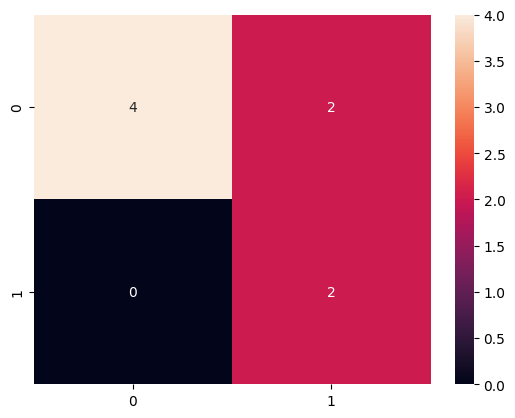

In [30]:
#Confusion Matrix
sns.heatmap(cm, annot=True)